# Notebook 5: Machine Learning - Predicting Inflation

**Goal:** Use energy prices and Hormuz tanker traffic to predict U.S. inflation.

**Contributors**: Joan Ojukwu

**Why this matters for the project:**
The comparative analysis showed *correlations*, that inflation and oil prices tend to move together. Machine learning takes the next step: can we actually *predict* how much inflation will change, given what we know about oil prices and shipping activity? If the model performs well, it validates that those correlations carry real predictive signal, not just coincidence.

**Two models:**
- **Linear Regression** — the simplest baseline. Draws a straight line through the data.
- **Ridge Regression** — same idea, but handles the fact that WTI and Brent move almost identically (r = 0.99). When two predictors are nearly identical, plain linear regression can behave erratically. Ridge prevents that.

**Data window:** Jan 2019 – Jul 2021 (31 months, all three datasets overlapping)

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import os
os.makedirs('figures', exist_ok=True)

## 2. Rebuild the Merged Dataset
Same merge as Notebook 4, using MoM inflation so we keep all 31 months.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_OUT = '/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles'

# CPI — cleaned file already has YearMonth and CPI columns
cpi = pd.read_csv(f'{BASE_OUT}/cpi_inflation_monthly.csv')
cpi['YearMonth'] = pd.to_datetime(cpi['YearMonth'])
cpi = cpi[['YearMonth', 'CPI']].set_index('YearMonth').sort_index()
cpi['MoM_pct'] = cpi['CPI'].pct_change(1).mul(100).round(4)

# Commodity prices — cleaned file already has WTI_Crude, Brent_Crude, Natural_Gas
res = pd.read_csv(f'{BASE_OUT}/commodity_prices_monthly.csv')
res['YearMonth'] = pd.to_datetime(res['YearMonth'])
res = res[['YearMonth', 'WTI_Crude', 'Brent_Crude', 'Natural_Gas']].rename(columns={
    'WTI_Crude': 'WTI', 'Brent_Crude': 'Brent', 'Natural_Gas': 'NatGas'})
res = res.set_index('YearMonth').sort_index()

# Hormuz — cleaned file already has YearMonth and monthly totals
hor = pd.read_csv(f'{BASE_OUT}/hormuz_arrivals_monthly.csv')
hor['YearMonth'] = pd.to_datetime(hor['YearMonth'])
hor = hor.set_index('YearMonth').sort_index()
hor = hor.rename(columns={'Total_Arrivals': 'Total'})

df = cpi.merge(res, on='YearMonth').merge(hor, on='YearMonth').dropna(subset=['MoM_pct'])
print('Rows:', len(df), '| Date range:', df.index.min().date(), '->', df.index.max().date())
df.head()

Rows: 18 | Date range: 2020-02-29 -> 2021-07-31


,CPI,MoM_pct,WTI,Brent,NatGas,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,disruption_flag,Total,Tanker_Share_pct
YearMonth,,,,,,,,,,,,,
2020-02-29,258.678,0.2741,50.7493,55.7455,1.8423,279,352,92,40,1182,0,1945,60.77
2020-03-31,258.115,-0.2176,30.5955,34.0200,1.7226,287,341,83,51,1248,0,2010,62.09
2020-04-30,256.389,-0.6687,18.2020,27.3653,1.7462,322,374,119,50,1411,0,2276,61.99
2020-05-31,256.394,0.0020,28.6832,32.2900,1.7997,370,414,120,61,1516,0,2481,61.10
2020-06-30,257.797,0.5472,38.3667,40.8493,1.6924,398,397,126,49,1564,0,2534,61.72


## 3. Define Features and Target

- **Features (X):** what we give the model to make a prediction — oil prices, natural gas, tanker arrivals
- **Target (y):** what we want to predict — monthly inflation rate

In [ ]:
FEATURES = ['WTI', 'Brent', 'NatGas', 'Tanker']
TARGET   = 'MoM_pct'

X = df[FEATURES]
y = df[TARGET]

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (18, 4)
Target shape: (18,)


## 4. Train / Test Split

We split the data **chronologically** train on earlier months, test on later months.

This is important because our data is ordered in time. If we shuffled randomly, we'd be training on 2021 data to predict 2019, which isn't realistic.

In [ ]:
split = int(len(df) * 0.70)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Train: {len(X_train)} months ({df.index[0].date()} to {df.index[split-1].date()})')
print(f'Test:  {len(X_test)} months ({df.index[split].date()} to {df.index[-1].date()})')

Train: 12 months (2020-02-29 to 2021-01-31)
Test:  6 months (2021-02-28 to 2021-07-31)


## 5. Scale the Features

WTI is measured in dollars (~$20-$70).

Tanker is measured in ship counts (~1,500).

Without scaling, Ridge would unfairly treat the larger numbers as more important.

`StandardScaler` puts every feature on the same scale (mean = 0, std = 1).

**Note:** We fit the scaler on training data only, then apply it to the test set. Never fit on test data — that would be using future information.

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

## 6. Model 1 — Linear Regression

The model learns the "best fit" relationship between energy prices and inflation during the training period, then applies that to the test months it has never seen.

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

r2_lr   = r2_score(y_test, pred_lr)
mae_lr  = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print('Linear Regression — Test Set Results')
print(f'  R²   : {r2_lr:.3f}  (1.0 = perfect, 0 = no better than guessing the mean)')
print(f'  MAE  : {mae_lr:.3f}  (average error in percentage points)')
print(f'  RMSE : {rmse_lr:.3f}  (penalizes large errors more than MAE)')

Linear Regression — Test Set Results
  R²   : -0.585  (1.0 = perfect, 0 = no better than guessing the mean)
  MAE  : 0.137  (average error in percentage points)
  RMSE : 0.197  (penalizes large errors more than MAE)


### Feature Coefficients

A positive coefficient means: when this variable goes up, predicted inflation goes up too. This connects back to the correlation analysis, the variables with the strongest correlations should also have the largest coefficients.

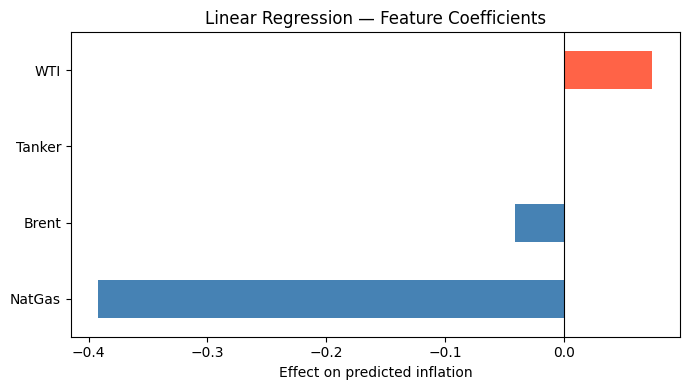

NatGas   -0.3917
Brent    -0.0410
Tanker    0.0009
WTI       0.0743
dtype: float64


In [ ]:
coef = pd.Series(lr.coef_, index=FEATURES).sort_values()

plt.figure(figsize=(7, 4))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef]
coef.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression — Feature Coefficients')
plt.xlabel('Effect on predicted inflation')
plt.tight_layout()
plt.savefig('figures/ml_coefficients.png', dpi=150)
plt.show()
print(coef.round(4))

## 7. Model 2 --> Ridge Regression

WTI and Brent crude have a correlation of r = 0.99 in our dataset — they are nearly the same variable. Plain linear regression responds to this by assigning them large, opposing coefficients that cancel each other out, which makes the model unstable.

Ridge adds a penalty that forces coefficients to stay small and stable. The `alpha` parameter controls how strong the penalty is. We test five values and pick the best.

In [ ]:
results = []
for a in [0.01, 0.1, 1.0, 10.0, 100.0]:
    m = Ridge(alpha=a).fit(X_train_s, y_train)
    p = m.predict(X_test_s)
    results.append({'alpha': a,
                    'R²':   round(r2_score(y_test, p), 3),
                    'MAE':  round(mean_absolute_error(y_test, p), 3),
                    'RMSE': round(np.sqrt(mean_squared_error(y_test, p)), 3)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best_alpha = results_df.loc[results_df['RMSE'].idxmin(), 'alpha']
print(f'\nBest alpha: {best_alpha}')

 alpha     R²   MAE  RMSE
  0.01 -0.687 0.143 0.204
  0.10 -1.410 0.188 0.243
  1.00 -2.115 0.218 0.277
 10.00 -0.418 0.170 0.187
100.00 -8.385 0.455 0.481

Best alpha: 10.0


In [ ]:
ridge = Ridge(alpha=best_alpha).fit(X_train_s, y_train)
pred_ridge = ridge.predict(X_test_s)

r2_r   = r2_score(y_test, pred_ridge)
mae_r  = mean_absolute_error(y_test, pred_ridge)
rmse_r = np.sqrt(mean_squared_error(y_test, pred_ridge))

print(f'Ridge (alpha={best_alpha}) — Test Set Results')
print(f'  R²   : {r2_r:.3f}')
print(f'  MAE  : {mae_r:.3f}')
print(f'  RMSE : {rmse_r:.3f}')

Ridge (alpha=10.0) — Test Set Results
  R²   : -0.418
  MAE  : 0.170
  RMSE : 0.187


## 8. Compare Both Models

In [ ]:
comparison = pd.DataFrame([
    {'Model': 'Linear Regression',          'R²': round(r2_lr,3), 'MAE': round(mae_lr,3), 'RMSE': round(rmse_lr,3)},
    {'Model': f'Ridge (alpha={best_alpha})', 'R²': round(r2_r,3),  'MAE': round(mae_r,3),  'RMSE': round(rmse_r,3)},
])
print('=== Model Comparison (test set only) ===')
print(comparison.to_string(index=False))

=== Model Comparison (test set only) ===
             Model     R²   MAE  RMSE
 Linear Regression -0.585 0.137 0.197
Ridge (alpha=10.0) -0.418 0.170 0.187


## 9. Actual vs Predicted - Test Set

This chart shows how well each model's predictions match what actually happened. It's the most intuitive way to communicate model performance.

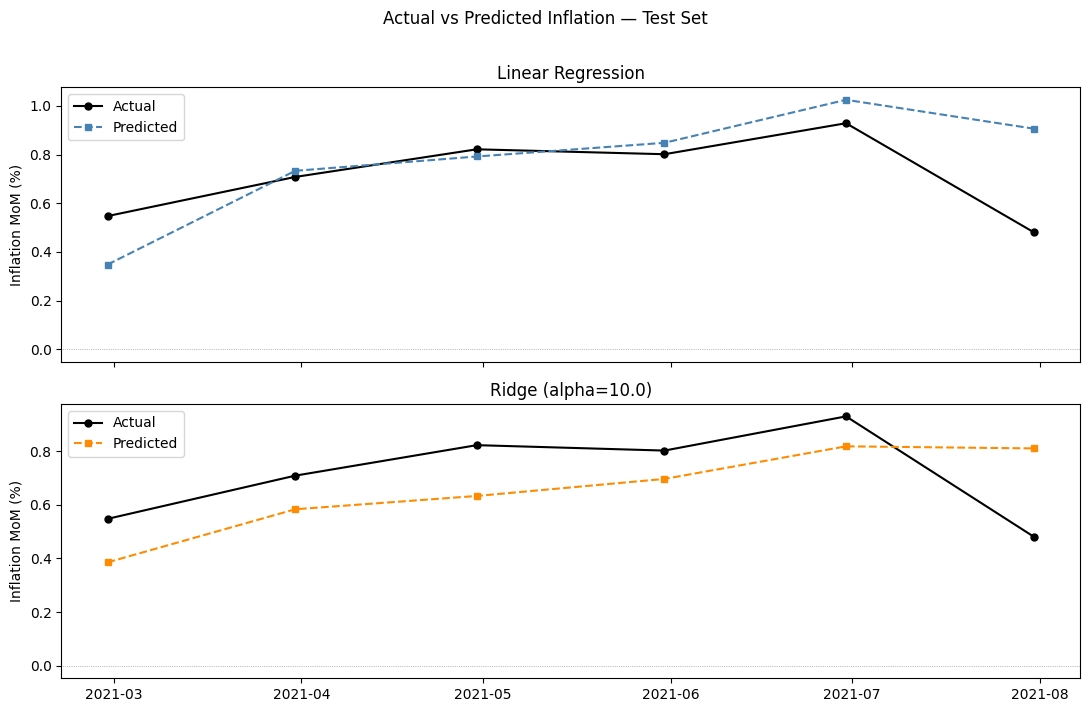

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

test_dates = df.index[split:]

for ax, preds, label, color in zip(
    axes,
    [pred_lr, pred_ridge],
    ['Linear Regression', f'Ridge (alpha={best_alpha})'],
    ['steelblue', 'darkorange']
):
    ax.plot(test_dates, y_test.values, color='black', marker='o', markersize=5, label='Actual')
    ax.plot(test_dates, preds, color=color, marker='s', markersize=5, linestyle='--', label='Predicted')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.set_title(label)
    ax.set_ylabel('Inflation MoM (%)')
    ax.legend()

plt.suptitle('Actual vs Predicted Inflation — Test Set', y=1.01)
plt.tight_layout()
plt.savefig('figures/ml_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary and Limitations

This prints the key numbers for the final report.

In [ ]:
print('RESULTS SUMMARY')
print(f'Training period : {df.index[0].date()} to {df.index[split-1].date()} ({split} months)')
print(f'Test period     : {df.index[split].date()} to {df.index[-1].date()} ({len(df)-split} months)')
print()
print(comparison.to_string(index=False))
print()
print('LIMITATIONS:')
print(f'  - Test set has only {len(df)-split} rows — treat results as directional, not definitive')
print('  - WTI and Brent are nearly identical predictors (r = 0.99) — Ridge handles this better')
print('  - All results are specific to the 2019-2021 window; the CPI dataset ends Jul 2021')
print('  - Models show correlation-based prediction, not causation')

RESULTS SUMMARY
Training period : 2020-02-29 to 2021-01-31 (12 months)
Test period     : 2021-02-28 to 2021-07-31 (6 months)

             Model     R²   MAE  RMSE
 Linear Regression -0.585 0.137 0.197
Ridge (alpha=10.0) -0.418 0.170 0.187

LIMITATIONS:
  - Test set has only 6 rows — treat results as directional, not definitive
  - WTI and Brent are nearly identical predictors (r = 0.99) — Ridge handles this better
  - All results are specific to the 2019-2021 window; the CPI dataset ends Jul 2021
  - Models show correlation-based prediction, not causation


Both models produced negative R² values on the test set, Linear Regression at −0.585 and Ridge at −0.418, meaning neither generalized successfully to the February–July 2021 test period. A negative R² indicates the model performed worse than simply predicting the mean inflation value for every month. Ridge regression outperformed Linear Regression on RMSE (0.187 vs 0.197), consistent with the expectation that regularization helps when predictors are highly correlated, as WTI and Brent are in this dataset (r = 0.99). MAE was 0.137 and 0.170 percentage points respectively. These results are directional only, the test set contains just 6 months, which is insufficient for stable evaluation. The test period also coincides with the sharpest inflation acceleration in the dataset, a regime the model had not seen enough of during the 12-month training window to predict reliably. The modeling exercise confirms that the strong correlations identified in the descriptive analysis do not straightforwardly translate into predictive power within this constrained window, which is itself an informative finding about the limitations of working with a small, time-bounded dataset.
